###Objective

Generate the final dataset that will be used for deep learning.

Input:

* Original CT DICOM scans
* pylidc annotations

Output:

* Cropped 3D lung nodule volumes (.npy)
* Metadata CSV containing labels and patch paths

##1. mount Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


##2. Install Packages

In [ ]:
!pip install -q pylidc pydicom scipy scikit-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.7 MB/s eta 0:00:00


##3. Import Required Libraries

In [ ]:
import os
from pathlib import Path

config_path = Path("/root/.pylidcrc")

config_content = """
[dicom]
path = /content/drive/MyDrive/Dissertation/Dataset/Raw
"""

config_path.write_text(config_content)

print("Created:", config_path)

print(config_path.read_text())
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import configparser
if not hasattr(configparser, "SafeConfigParser"):
    configparser.SafeConfigParser = configparser.ConfigParser

from tqdm import tqdm

Created: /root/.pylidcrc

[dicom]
path = /content/drive/MyDrive/Dissertation/Dataset/Raw



##4. NumPy Compatibility

In [ ]:
if not hasattr(np, "int"):
    np.int = int

if not hasattr(np, "float"):
    np.float = float

if not hasattr(np, "bool"):
    np.bool = bool
import pylidc as pl


##5. Dataset Path

In [ ]:
RAW_PATH = Path(
    "/content/drive/MyDrive/Dissertation/Dataset/Raw"
)

PROCESSED_PATH = Path(
    "/content/drive/MyDrive/Dissertation/Dataset/Processed"
)

XML_PATH = DRIVE_ROOT / "Dataset" / "ANNOTATION_STAGING"

PATCH_PATH = PROCESSED_PATH / "NodulePatches"

PATCH_PATH.mkdir(
    parents=True,
    exist_ok=True
)

MASK_PATH = (
    PROCESSED_PATH /
    "NoduleMasks"
)

MASK_PATH.mkdir(
    parents=True,
    exist_ok=True
)


In [ ]:
from pathlib import Path
from datetime import datetime
import pandas as pd

LOG_FILE = PROCESSED_PATH / "processing_log.csv"
DATASET_FILE = PROCESSED_PATH / "nodule_dataset.csv"

if LOG_FILE.exists():

    processing_log = pd.read_csv(LOG_FILE)

else:

    processing_log = pd.DataFrame(
        columns=[
            "PatientID",
            "Status",
            "Nodules",
            "ProcessedTime",
            "Error"
        ]
    )

if DATASET_FILE.exists():

    dataset_df = pd.read_csv(DATASET_FILE)

else:

    dataset_df = pd.DataFrame()

processed_patients = set(

    processing_log.loc[
        processing_log.Status=="Completed",
        "PatientID"
    ]

)

print("Already processed:",len(processed_patients))

Already processed: 0


##6. Load Database

In [ ]:
scans = pl.query(pl.Scan).all()

print("Total scans:", len(scans))

Total scans: 1018


##7. Create Patient Lookup

In [ ]:
patient_folders = sorted([
    p.name
    for p in RAW_PATH.iterdir()
    if p.is_dir()
])

print(patient_folders)

['LIDC-IDRI-0001', 'LIDC-IDRI-0002', 'LIDC-IDRI-0003', 'LIDC-IDRI-0004', 'LIDC-IDRI-0005', 'LIDC-IDRI-0006', 'LIDC-IDRI-0007', 'LIDC-IDRI-0008', 'LIDC-IDRI-0009', 'LIDC-IDRI-0010']


##8. Keep Only Available Patients

In [ ]:
available_scans = []

for scan in scans:

    if scan.patient_id in patient_folders:

        available_scans.append(scan)

print("Available scans:", len(available_scans))

Available scans: 10


In [ ]:
##9. Select First Patient

In [ ]:
scan = available_scans[0]

print("Patient:", scan.patient_id)

print("Study UID:", scan.study_instance_uid)

print("Series UID:", scan.series_instance_uid)

Patient: LIDC-IDRI-0001
Study UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288633453246975630178
Series UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192


##10. Cluser Annotations

In [ ]:
clusters = scan.cluster_annotations()

print("Clusters:", len(clusters))

for i, cluster in enumerate(clusters):

    print(
        f"Cluster {i+1}:",
        len(cluster),
        "reader(s)"
    )

Clusters: 1
Cluster 1: 4 reader(s)


##11. Select One Physical Nodule

In [ ]:
cluster = clusters[0]

print("Number of annotations:", len(cluster))

Number of annotations: 4


##12. Consensus Malignancy

In [ ]:
malignancy_scores = [
    ann.malignancy
    for ann in cluster
]

print("Reader Scores:")

print(malignancy_scores)

print()

print(
    "Mean:",
    np.mean(malignancy_scores)
)

print(
    "Median:",
    np.median(malignancy_scores)
)

Reader Scores:
[5, 5, 5, 4]

Mean: 4.75
Median: 5.0


##13. Load CT Volume

In [ ]:
volume = scan.to_volume()

print("Volume shape:", volume.shape)

print("Data type:", volume.dtype)

print("Minimum:", volume.min())

print("Maximum:", volume.max())

Loading dicom files ... This may take a moment.
Volume shape: (512, 512, 133)
Data type: int16
Minimum: -2048
Maximum: 3071


##14. Generate Consensus Mask
pylidc provides multiple annotations from multiple radiologists. We need to combine them into a single consensus mask.

In [ ]:
from pylidc.utils import consensus

PADDING = 20

mask, bbox, masks = consensus(
    cluster,
    clevel=0.5,
    pad=[
        (PADDING, PADDING),
        (PADDING, PADDING),
        (2, 2)
    ]
)

print("Mask shape:", mask.shape)

print("Bounding box:")
print(bbox)

Mask shape: (92, 84, 13)
Bounding box:
(slice(np.int64(320), np.int64(412), None), slice(np.int64(277), np.int64(361), None), slice(np.int64(84), np.int64(97), None))


##15. Verify Mask Dimensions

In [ ]:
print("CT volume:")
print(volume.shape)

print()

print("Mask:")
print(mask.shape)

CT volume:
(512, 512, 133)

Mask:
(92, 84, 13)


##16. Extract Nodule Patch

In [ ]:
nodule_patch = volume[
    bbox[0],
    bbox[1],
    bbox[2]
].copy()

print(
    "Nodule patch shape:",
    nodule_patch.shape
)

Nodule patch shape: (92, 84, 13)


##17. Confirm Patch and Mask Alignment

In [ ]:
print(
    "Patch:",
    nodule_patch.shape
)

print(
    "Mask:",
    mask.shape
)

Patch: (92, 84, 13)
Mask: (92, 84, 13)


##18. Visualize Extracted Nodule

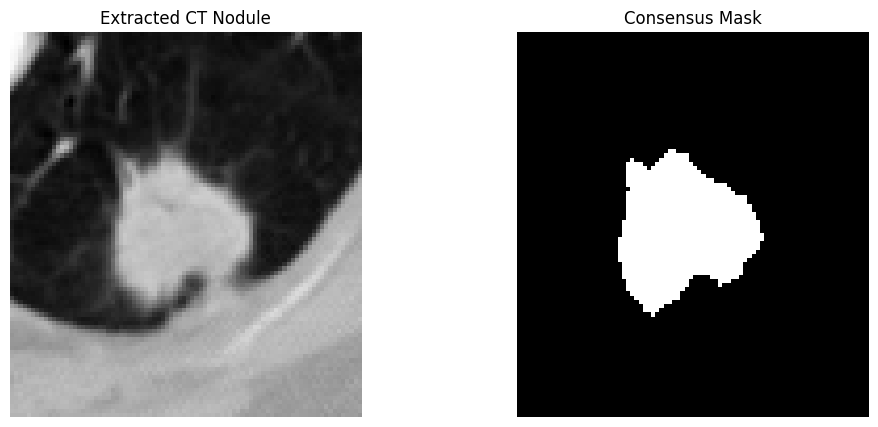

In [ ]:
middle = nodule_patch.shape[2] // 2


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.imshow(
    nodule_patch[:,:,middle],
    cmap="gray"
)

plt.title("Extracted CT Nodule")

plt.axis("off")



plt.subplot(1,2,2)

plt.imshow(
    mask[:,:,middle],
    cmap="gray"
)

plt.title("Consensus Mask")

plt.axis("off")


plt.show()

##19. Apply Mask

In [ ]:
binary_mask = mask.astype(bool)

masked_patch = nodule_patch.copy()

masked_patch[~binary_mask] = -1024

masked_patch = np.clip(masked_patch, -1000, 400)

####Visualize:

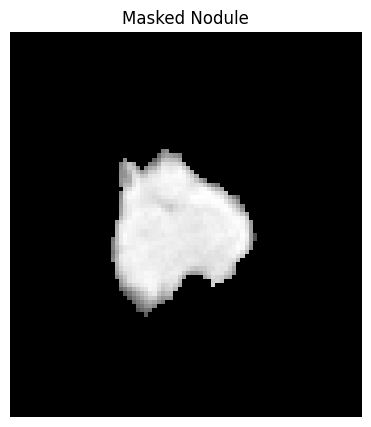

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(
    masked_patch[:,:,middle],
    cmap="gray"
)

plt.title("Masked Nodule")

plt.axis("off")

plt.show()

##20. Save First Test Patch

In [ ]:
test_file = (
    PATCH_PATH /
    f"{scan.patient_id}_nodule_test.npy"
)


np.save(
    test_file,
    masked_patch
)


print(
    "Saved:",
    test_file
)

Saved: /content/drive/MyDrive/Dissertation/Dataset/Processed/NodulePatches/LIDC-IDRI-0001_nodule_test.npy


##21. Create Extraction Function

####Function 1: Convert malignancy score to binary label

In [ ]:
def malignancy_label(score):

    if score >= 4:
        return 1   # malignant

    else:
        return 0   # benign

##22. Create Nodule Extraction Function

In [ ]:
def extract_nodule(
    volume,
    scan,
    cluster,
    save_path,
    nodule_id
):

    try:

        # Generate consensus mask
        PADDING = 20

        mask, bbox, masks = consensus(
            cluster,
            clevel=0.5,
            pad=[
                (PADDING, PADDING),
                (PADDING, PADDING),
                (2, 2)
            ]
        )

        # Ignore extremely tiny nodules
        if mask.sum() < 50:
            return None



        # Crop CT
        patch = volume[
            bbox[0],
            bbox[1],
            bbox[2]
        ]

        binary_mask = mask.astype(bool)

        raw_patch = patch.copy()

        masked_patch = patch.copy()

        masked_patch[~binary_mask] = -1024

        masked_patch = np.clip(masked_patch, -1000, 400)


        # Save
        filename = (
            f"{scan.patient_id}_"
            f"nodule_{nodule_id:03d}.npy"
        )


        filepath = save_path / filename


        np.save(
            filepath,
            raw_patch.astype(np.int16)
        )

        mask_file = (
            MASK_PATH /
            f"{scan.patient_id}_nodule_{nodule_id:03d}_mask.npy"
        )

        np.save(mask_file, binary_mask.astype(np.uint8))



        # Malignancy information

        scores = [
            ann.malignancy
            for ann in cluster
        ]


        mean_malignancy = np.mean(scores)


        return {

            "PatientID":
                scan.patient_id,

            "NoduleID":
                nodule_id,

            "PatchPath":
                str(filepath),

            "PatchShape":
                str(patch.shape),

            "Readers":
                len(cluster),

            "MeanMalignancy":
                mean_malignancy,

            "MedianMalignancy":
                np.median(scores),

            "CancerLabel":
                malignancy_label(
                    mean_malignancy
                ),

            "MaskedPatchPath": str(mask_file),

            "MaskPath": str(mask_file),
            "MaskVoxelCount" : int(mask.sum())

        }


    except Exception as e:

        print(
            "Failed:",
            scan.patient_id,
            nodule_id,
            e
        )

        return None

##23. Test Function on Current Patient

In [ ]:
# Load CT once
volume = scan.to_volume()
test_result = extract_nodule(
    volume,
    scan,
    cluster,
    PATCH_PATH,
    1
)

test_result

Loading dicom files ... This may take a moment.


{'PatientID': 'LIDC-IDRI-0001',
 'NoduleID': 1,
 'PatchPath': '/content/drive/MyDrive/Dissertation/Dataset/Processed/NodulePatches/LIDC-IDRI-0001_nodule_001.npy',
 'PatchShape': '(92, 84, 13)',
 'Readers': 4,
 'MeanMalignancy': np.float64(4.75),
 'MedianMalignancy': np.float64(5.0),
 'CancerLabel': 1,
 'MaskedPatchPath': '/content/drive/MyDrive/Dissertation/Dataset/Processed/NoduleMasks/LIDC-IDRI-0001_nodule_001_mask.npy',
 'MaskPath': '/content/drive/MyDrive/Dissertation/Dataset/Processed/NoduleMasks/LIDC-IDRI-0001_nodule_001_mask.npy',
 'MaskVoxelCount': 5428}

##24. Process All Available Scans

In [ ]:
from tqdm import tqdm

all_records = []

for scan in tqdm(
    available_scans,
    desc="Processing patients"
):

    # Resume support
    if scan.patient_id in processed_patients:
        print(f"Skipping {scan.patient_id}")
        continue

    print(f"\nProcessing: {scan.patient_id}")

    # Check if patient already exists in dataset CSV
    existing_dataset_patients = set()

    if DATASET_FILE.exists():

        existing = pd.read_csv(
            DATASET_FILE,
            usecols=["PatientID"]
        )

        existing_dataset_patients = set(
            existing["PatientID"]
        )

        if scan.patient_id in existing_dataset_patients:

            print(f"{scan.patient_id} already exists in dataset. Skipping.")

            continue

    try:

        # Load CT only once
        volume = scan.to_volume()

        clusters = scan.cluster_annotations()

        patient_records = []

        for idx, cluster in enumerate(clusters):

            result = extract_nodule(
                volume,
                scan,
                cluster,
                PATCH_PATH,
                idx + 1
            )

            if result is not None:

              if not Path(result["PatchPath"]).exists():

                  raise FileNotFoundError(result["PatchPath"])

              if not Path(result["MaskPath"]).exists():

                  raise FileNotFoundError(result["MaskPath"])

              patient_records.append(result)

        # Save immediately
        if len(patient_records) > 0:

            patient_df = pd.DataFrame(patient_records)

            if DATASET_FILE.exists():

                patient_df.to_csv(
                    DATASET_FILE,
                    mode="a",
                    header=False,
                    index=False
                )

            else:

                patient_df.to_csv(
                    DATASET_FILE,
                    index=False
                )

            all_records.extend(patient_records)

        processing_log.loc[len(processing_log)] = [
            scan.patient_id,
            "Completed",
            len(patient_records),

            datetime.now(),
            ""
        ]

    except Exception as e:

        print(f"ERROR: {scan.patient_id}")
        print(e)

        processing_log.loc[len(processing_log)] = [
            scan.patient_id,
            "Failed",
            0,

            datetime.now(),

            str(e)
        ]

    # Save checkpoint after every patient
    processing_log.to_csv(LOG_FILE, index=False)

Processing patients:   0%|          | 0/10 [00:00<?, ?it/s]


Processing LIDC-IDRI-0001

Processing: LIDC-IDRI-0001
Loading dicom files ... This may take a moment.


Processing patients:  10%|█         | 1/10 [00:02<00:20,  2.32s/it]

ERROR: LIDC-IDRI-0001
'list' object has no attribute 'patient_id'

Processing LIDC-IDRI-0002

Processing: LIDC-IDRI-0002
Loading dicom files ... This may take a moment.


Processing patients:  20%|██        | 2/10 [00:14<01:05,  8.24s/it]

...

ERROR: LIDC-IDRI-0008
'list' object has no attribute 'patient_id'

Processing LIDC-IDRI-0009

Processing: LIDC-IDRI-0009
Loading dicom files ... This may take a moment.


Processing patients:  90%|█████████ | 9/10 [01:11<00:08,  8.48s/it]

ERROR: LIDC-IDRI-0009
'list' object has no attribute 'patient_id'

Processing LIDC-IDRI-0010

Processing: LIDC-IDRI-0010
Loading dicom files ... This may take a moment.


Processing patients: 100%|██████████| 10/10 [01:29<00:00,  8.98s/it]

ERROR: LIDC-IDRI-0010
'list' object has no attribute 'patient_id'


In [ ]:
if (len(processing_log) % 25)==0:

    print()

    print("="*50)

    print(processing_log.Status.value_counts())

    print()

    print("Dataset size:",
          len(pd.read_csv(DATASET_FILE)))

    print("="*50)

In [ ]:
if len(patient_records) > 0:

    patient_df = pd.DataFrame(patient_records)

    if DATASET_FILE.exists():

        patient_df.to_csv(

            DATASET_FILE,

            mode="a",

            header=False,

            index=False

        )

    else:

        patient_df.to_csv(

            DATASET_FILE,

            index=False

        )

##25. Convert Results to DataFrame

In [ ]:
dataset_df = pd.read_csv(DATASET_FILE)

print(dataset_df.shape)

dataset_df.head()


print(
    "Total extracted nodules:",
    len(dataset_df)
)


##26. Check Class Distribution

In [ ]:
dataset_df["CancerLabel"].value_counts()

##27. Save Metadata CSV

In [ ]:
metadata_output = (
    PROCESSED_PATH /
    "nodule_dataset.csv"
)


dataset_df.to_csv(
    metadata_output,
    index=False
)


print(
    "Saved:",
    metadata_output
)

In [ ]:
processing_log.loc[len(processing_log)] = [

    scan.patient_id,

    "Completed",

    len(patient_records),
    datetime.now(),

    ""

]

processing_log.to_csv(

    LOG_FILE,

    index=False

)

##28. Import Required Packages

In [ ]:
import gc
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

##29. Create Output Directories

In [ ]:
PATCH_PATH = (
    PROCESSED_PATH /
    "NodulePatches"
)

PATCH_PATH.mkdir(
    parents=True,
    exist_ok=True
)

##30. Metadata File

In [ ]:
metadata_csv = (
    PROCESSED_PATH /
    "nodule_dataset.csv"
)

##31. Resume Capability
####If Colab disconnects after processing 500 patients the notebook simply continues.

In [ ]:
processed_patients = set()

if metadata_csv.exists():

    existing = pd.read_csv(metadata_csv)

    processed_patients = set(
        existing["PatientID"].unique()
    )

print(
    "Already processed:",
    len(processed_patients)
)

##32. Metadata Buffer

In [ ]:
records = []

##33. Optimized Main Loop

In [ ]:
for scan in tqdm(
    scans,
    desc="Processing Patients"
):

    if scan.patient_id not in patient_folders:
        continue

    if scan.patient_id in processed_patients:
        print(f"Skipping {scan.patient_id}")
        continue

    print(f"\nProcessing {scan.patient_id}")

    try:

        # Load CT only once
        volume = scan.to_volume()

        clusters = scan.cluster_annotations()

        patient_records = []

        for idx, cluster in enumerate(clusters):

            result = extract_nodule(
                volume,
                scan,
                cluster,
                PATCH_PATH,
                idx + 1
            )

            if result is not None:
                patient_records.append(result)

        # Save metadata immediately
        if len(patient_records) > 0:

            df = pd.DataFrame(patient_records)

            if metadata_csv.exists():

                df.to_csv(
                    metadata_csv,
                    mode="a",
                    header=False,
                    index=False
                )

            else:

                df.to_csv(
                    metadata_csv,
                    index=False
                )

        del volume
        gc.collect()

    except Exception as e:

        print(
            scan.patient_id,
            e
        )

##34. Final Verification

In [ ]:
dataset = pd.read_csv(metadata_csv)

print(dataset.shape)

dataset.head()

##35. verify Path Files

In [ ]:
missing = []

for path in dataset["PatchPath"]:

    if not os.path.exists(path):
        missing.append(path)

print("Missing patches:", len(missing))

##36. Dataset Statistics

In [ ]:
print(dataset["CancerLabel"].value_counts())

print()

print(dataset["MeanMalignancy"].describe())

In [ ]:
dataset = pd.read_csv(DATASET_FILE)

print("="*60)

print("SUMMARY")

print("="*60)

print()

print("Patients completed")

print(
    processing_log.Status.value_counts()
)

print()

print("Unique patients")

print(
    dataset.PatientID.nunique()
)

print()

print("Total nodules")

print(len(dataset))

print()

print("Cancer labels")

print(
    dataset.CancerLabel.value_counts()
)

print()

print("Missing patches")

print(

    dataset.PatchPath.apply(
        lambda x: not Path(x).exists()
    ).sum()

)

print()

print("Missing masks")

print(

    dataset.MaskPath.apply(
        lambda x: not Path(x).exists()
    ).sum()

)